# The CIFAR-10 dataset

In [4]:
import numpy as np
from tensorflow.keras.datasets import mnist
import keras
import sys
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


NB_CLASSES = 10
NB_INPUTS = 784 # 28x28

## 2.1 The dataset

In [31]:
from tensorflow.keras.datasets import cifar10
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 92s 1us/step


c:\Users\auber.MSI\Projets\Machine-Learning\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [32]:
print(x_train_cifar.shape, y_train_cifar.shape)
print(x_test_cifar.shape, y_test_cifar.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


### 2.1.1 Image display

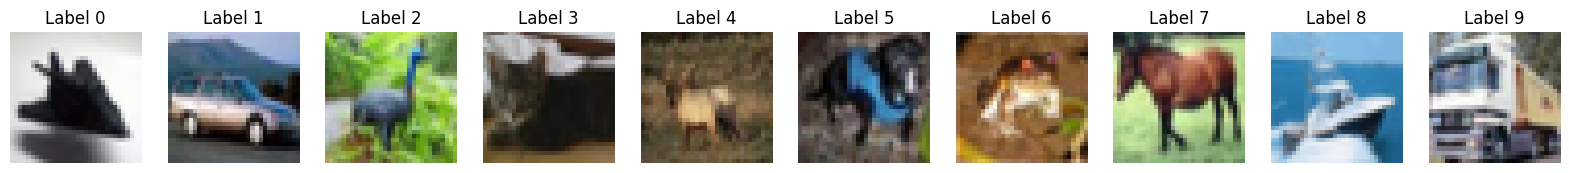

In [33]:
f, ax = plt.subplots(1, 10, figsize=(20,5))

for i in range(10):
    sample = x_train_cifar[y_train_cifar.flatten() == i][0]
    ax[i].imshow(sample)
    ax[i].set_title(f'Label {i}')
    ax[i].axis('off')

## 2.2 Preliminary work

### 2.2.1 RGP to grayscale

In [34]:
def rgb_to_gray(x):
    return 0.299*x[:,:,:,0] + 0.587*x[:,:,:,1] + 0.114*x[:,:,:,2]

x_train_gray = rgb_to_gray(x_train_cifar)
x_test_gray  = rgb_to_gray(x_test_cifar)

### 2.2.2 Reshape

In [35]:
x_train_cifar = x_train_gray.reshape(x_train_gray.shape[0], -1)
x_test_cifar  = x_test_gray.reshape(x_test_gray.shape[0], -1)

print("Train:", x_train_cifar.shape)
print("Test:", x_test_cifar.shape)

Train: (50000, 1024)
Test: (10000, 1024)


In [36]:
x_train_cifar = x_train_cifar / 255.0
x_test_cifar  = x_test_cifar / 255.0

print(x_train_cifar.shape)
print(x_test_cifar.shape)

(50000, 1024)
(10000, 1024)


### 2.2.4 Classification : Linear model

In [37]:
y_train_cifar = y_train_cifar.flatten()
y_test_cifar  = y_test_cifar.flatten()

y_train_cifar = keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar  = keras.utils.to_categorical(y_test_cifar, 10)

print(y_test_cifar.shape)

(10000, 10)


In [38]:
NB_CLASSES = 10
NB_INPUTS_CIFAR = 1024

np.random.seed(42)
A_cifar = np.random.randn(NB_CLASSES, NB_INPUTS_CIFAR) * 0.01
b_cifar = np.zeros((1, NB_CLASSES))

In [39]:
LEARNING_RATE = 0.2

loss_history_linear_cifar = []
accuracy_history_linear_cifar = []

for i in range(100):

    # Forward
    O = x_train_cifar @ A_cifar.T + b_cifar
    P = softmax(O)

    # Loss + accuracy
    L = loss(y_train_cifar, P)
    loss_history_linear_cifar.append(L)
    accuracy_history_linear_cifar.append(accuracy(y_train_cifar, P))

    # Backprop
    dA, db = gradient_descent(x_train_cifar, y_train_cifar, P, x_train_cifar.shape[0])

    # Update
    A_cifar -= LEARNING_RATE * dA
    b_cifar -= LEARNING_RATE * db

    # Print
    print(f"Iteration {i}: Loss = {L:.4f}, Accuracy = {accuracy_history_linear_cifar[-1]*100:.2f}%")

Iteration 0: Loss = 2.3109, Accuracy = 9.37%
Iteration 1: Loss = 2.4116, Accuracy = 13.19%
Iteration 2: Loss = 3.2625, Accuracy = 12.98%
Iteration 3: Loss = 4.3775, Accuracy = 12.42%
Iteration 4: Loss = 4.5380, Accuracy = 14.21%
Iteration 5: Loss = 5.1725, Accuracy = 9.95%
Iteration 6: Loss = 6.1179, Accuracy = 11.01%
Iteration 7: Loss = 6.7168, Accuracy = 10.65%
Iteration 8: Loss = 7.1168, Accuracy = 15.69%
Iteration 9: Loss = 7.6237, Accuracy = 12.27%
Iteration 10: Loss = 7.0727, Accuracy = 10.09%
Iteration 11: Loss = 6.8008, Accuracy = 14.38%
Iteration 12: Loss = 8.2907, Accuracy = 13.36%
Iteration 13: Loss = 8.8755, Accuracy = 10.29%
Iteration 14: Loss = 8.7256, Accuracy = 12.97%
Iteration 15: Loss = 9.4430, Accuracy = 12.24%
Iteration 16: Loss = 8.0728, Accuracy = 15.73%
Iteration 17: Loss = 8.9911, Accuracy = 11.12%
Iteration 18: Loss = 8.5211, Accuracy = 12.51%
Iteration 19: Loss = 8.2809, Accuracy = 16.79%
Iteration 20: Loss = 7.4542, Accuracy = 12.85%
Iteration 21: Loss = 7.66

In [40]:
pred_test_lin_cifar = softmax(x_test_cifar @ A_cifar.T + b_cifar)

print("Linear model error (CIFAR):", error_rate(y_test_cifar, pred_test_lin_cifar))
print("Linear model accuracy (CIFAR):", accuracy(y_test_cifar, pred_test_lin_cifar))

Linear model error (CIFAR): 0.8219
Linear model accuracy (CIFAR): 0.1781


### 2.2.5 Classification : MLP model

In [41]:
p1 = 256  # hidden layer size

np.random.seed(42)

a1_cifar = np.random.randn(p1, 1024) * np.sqrt(2. / p1)
b1_cifar = np.zeros((1, p1))

a2_cifar = np.random.randn(10, p1) * np.sqrt(2. / p1)
b2_cifar = np.zeros((1, 10))

In [42]:
loss_h1_cifar = []
accuracy_h1_cifar = []

for i in range(100):

    # Forward
    O1 = x_train_cifar @ a1_cifar.T + b1_cifar
    Z1 = relu(O1)

    O2 = Z1 @ a2_cifar.T + b2_cifar
    P = softmax(O2)

    # Loss
    L = loss(y_train_cifar, P)
    loss_h1_cifar.append(L)
    accuracy_h1_cifar.append(accuracy(y_train_cifar, P))

    # Backprop
    dO2 = (P - y_train_cifar) / x_train_cifar.shape[0]
    da2 = dO2.T @ Z1
    db2 = np.sum(dO2, axis=0, keepdims=True)

    dZ1 = dO2 @ a2_cifar * relu_derivative(O1)
    da1 = dZ1.T @ x_train_cifar
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    a2_cifar -= LEARNING_RATE * da2
    b2_cifar -= LEARNING_RATE * db2
    a1_cifar -= LEARNING_RATE * da1
    b1_cifar -= LEARNING_RATE * db1

    print(f'Loss at iteration {i}: {L:.4f}, Accuracy: {accuracy_h1_cifar[-1]*100:.2f}%')

Loss at iteration 0: 2.9866, Accuracy: 8.28%
Loss at iteration 1: 5.9297, Accuracy: 10.96%
Loss at iteration 2: 4.5593, Accuracy: 11.65%
Loss at iteration 3: 2.6707, Accuracy: 11.87%
Loss at iteration 4: 2.2798, Accuracy: 14.16%
Loss at iteration 5: 2.2670, Accuracy: 16.02%
Loss at iteration 6: 2.2564, Accuracy: 16.41%
Loss at iteration 7: 2.2468, Accuracy: 16.76%
Loss at iteration 8: 2.2377, Accuracy: 17.03%
Loss at iteration 9: 2.2289, Accuracy: 17.27%
Loss at iteration 10: 2.2202, Accuracy: 17.74%
Loss at iteration 11: 2.2114, Accuracy: 18.28%
Loss at iteration 12: 2.2027, Accuracy: 18.94%
Loss at iteration 13: 2.1943, Accuracy: 19.39%
Loss at iteration 14: 2.1862, Accuracy: 19.95%
Loss at iteration 15: 2.1783, Accuracy: 20.36%
Loss at iteration 16: 2.1707, Accuracy: 20.88%
Loss at iteration 17: 2.1633, Accuracy: 21.39%
Loss at iteration 18: 2.1564, Accuracy: 21.80%
Loss at iteration 19: 2.1498, Accuracy: 22.19%
Loss at iteration 20: 2.1437, Accuracy: 22.50%
Loss at iteration 21: 2.

In [43]:
pred_test_h1_cifar = softmax(relu(x_test_cifar @ a1_cifar.T + b1_cifar) @ a2_cifar.T + b2_cifar)

print("MLP error (CIFAR):", error_rate(y_test_cifar, pred_test_h1_cifar))
print("MLP accuracy (CIFAR):", accuracy(y_test_cifar, pred_test_h1_cifar))

MLP error (CIFAR): 0.7149
MLP accuracy (CIFAR): 0.2851


### 2.2.6 Error rate

In [44]:
error_train_cifar = {}

# Predictions on training set
pred_train_lin_cifar = softmax(x_train_cifar @ A_cifar.T + b_cifar)
pred_train_h1_cifar  = softmax(relu(x_train_cifar @ a1_cifar.T + b1_cifar) @ a2_cifar.T + b2_cifar)

# Linear
error_train_cifar['Linear'] = error_rate(y_train_cifar, pred_train_lin_cifar)

# 1 hidden layer
error_train_cifar['1HL'] = error_rate(y_train_cifar, pred_train_h1_cifar)

In [45]:
error_test_cifar = {}

# Predictions on test set
pred_test_lin_cifar = softmax(x_test_cifar @ A_cifar.T + b_cifar)
pred_test_h1_cifar  = softmax(
    relu(x_test_cifar @ a1_cifar.T + b1_cifar) @ a2_cifar.T + b2_cifar
)

# Linear
error_test_cifar['Linear'] = error_rate(y_test_cifar, pred_test_lin_cifar)

# 1 hidden layer
error_test_cifar['1HL'] = error_rate(y_test_cifar, pred_test_h1_cifar)

In [46]:
models = ['Linear', '1HL']

print(f"{'Model':<20} {'Train error':>22} {'Test error':>22}")
print("-" * 75)

for i in range(len(models)):
    print(f"{models[i]:<20} {error_train_cifar[models[i]]*100:>20.2f}% {error_test_cifar[models[i]]*100:>20.2f}%")

Model                           Train error             Test error
---------------------------------------------------------------------------
Linear                              82.33%                82.19%
1HL                                 71.32%                71.49%
